In [1]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load data and inspect
posts_df = pd.read_csv("data/posts_no_dupes.csv")
posts_df.head(3)

,uri,author_handle,author_did,text,created_at,reply_count,repost_count,quote_count,like_count,is_reply,reply_parent,keyword


In [3]:
posts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   uri            0 non-null      object
 1   author_handle  0 non-null      object
 2   author_did     0 non-null      object
 3   text           0 non-null      object
 4   created_at     0 non-null      object
 5   reply_count    0 non-null      object
 6   repost_count   0 non-null      object
 7   quote_count    0 non-null      object
 8   like_count     0 non-null      object
 9   is_reply       0 non-null      object
 10  reply_parent   0 non-null      object
 11  keyword        0 non-null      object
dtypes: object(12)
memory usage: 132.0+ bytes


`created_at` is a string, needs to be converted to date time format

In [4]:
# convert created_at to datetime
posts_df['created_at'] = pd.to_datetime(posts_df['created_at'], format='ISO8601')

In [5]:
posts_df.describe()

,created_at
count,0
mean,NaT
min,NaT
25%,NaT
50%,NaT
75%,NaT
max,NaT


In [6]:
# Check distribution of replies vs original posts
print(posts_df['is_reply'].value_counts())
print(f"\nReply rate: {posts_df['is_reply'].mean():.1%}")

Series([], Name: count, dtype: int64)

Reply rate: nan%


In [7]:
print(f"Number of unique authors: {posts_df['author_handle'].nunique()}")
print(f"Number of unique posts: {posts_df['uri'].nunique()}")
print(f"Date range: {posts_df['created_at'].min()} to {posts_df['created_at'].max()}")

print(f"Top 20 most active authors: {posts_df['author_handle'].value_counts().head(20)}")

Number of unique authors: 0
Number of unique posts: 0
Date range: NaT to NaT
Top 20 most active authors: Series([], Name: count, dtype: int64)


Looks like there is some bot accounts in the in the most active posters. e.g.:
- `bbcmotdbot.bsky.social`
- `hltv-mirror.eurosky.social`
- `bot-unixporn.bsky.social ` 

Probably should remove these 

In [8]:
# TODO - check for bot accounts

In [9]:
# Check for duplicates
print(f"{len(posts_df['uri'])} total rows in dataset")
print(f"{posts_df['uri'].nunique()} unique post URIs")

# drop duplicates if any
posts_df = posts_df.drop_duplicates(subset='uri')
print(f"{len(posts_df)} rows remaining after removing duplicates")

0 total rows in dataset
0 unique post URIs
0 rows remaining after removing duplicates


In [10]:
posts_df['reply_count'].value_counts()

Series([], Name: count, dtype: int64)

Reply count of 0 and 1 are large, filter those out and we can see the distribution

In [14]:
print(posts_df.shape)
print(posts_df.dtypes)
print(posts_df.head(2))

(0, 13)
uri                     object
author_handle           object
author_did              object
text                    object
created_at       datetime64[s]
reply_count             object
repost_count            object
quote_count             object
like_count              object
is_reply                object
reply_parent            object
keyword                 object
month                period[M]
dtype: object
Empty DataFrame
Columns: [uri, author_handle, author_did, text, created_at, reply_count, repost_count, quote_count, like_count, is_reply, reply_parent, keyword, month]
Index: []


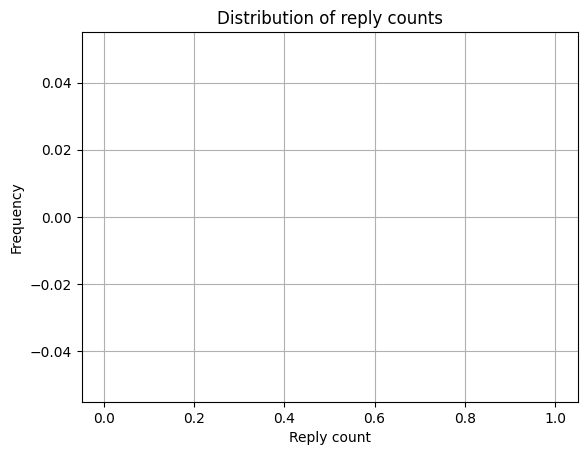

In [11]:
# check reply_count value counts
posts_df['reply_count'].value_counts().hist(bins=40)
plt.title('Distribution of reply counts')
plt.xlabel('Reply count')
plt.ylabel('Frequency')
plt.show()

Still heavily right skewed, major reply chain is over 800 (vegeta voice)

C:\Users\danie\AppData\Local\Temp\ipykernel_24940\814882044.py:8: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


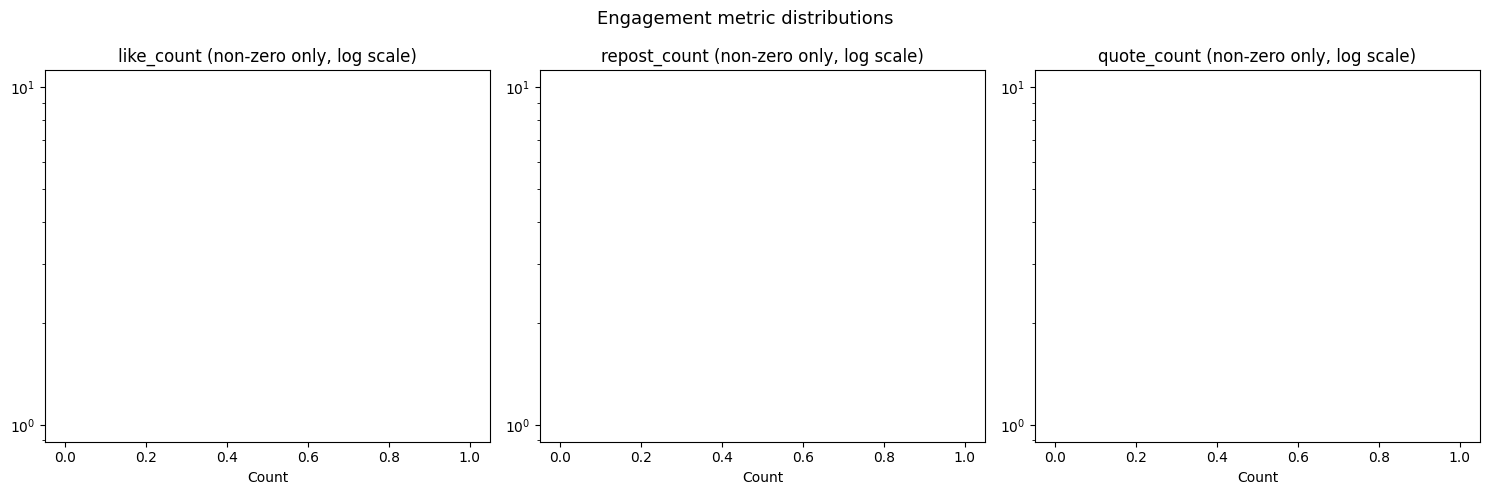

In [12]:
# plot histograms of engagement metrics (likes, reposts, replies, quotes)
num_cols = ['like_count', 'repost_count', 'quote_count']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes.flat, num_cols):
    data = posts_df[col][posts_df[col] > 0]  # exclude zeros for log scale
    ax.hist(data, bins=40, color='steelblue', edgecolor='none')
    ax.set_yscale('log')
    ax.set_title(f'{col} (non-zero only, log scale)')
    ax.set_xlabel('Count')
fig.suptitle('Engagement metric distributions', fontsize=13)
plt.tight_layout()
plt.show()

ValueError: zero-size array to reduction operation fmin which has no identity

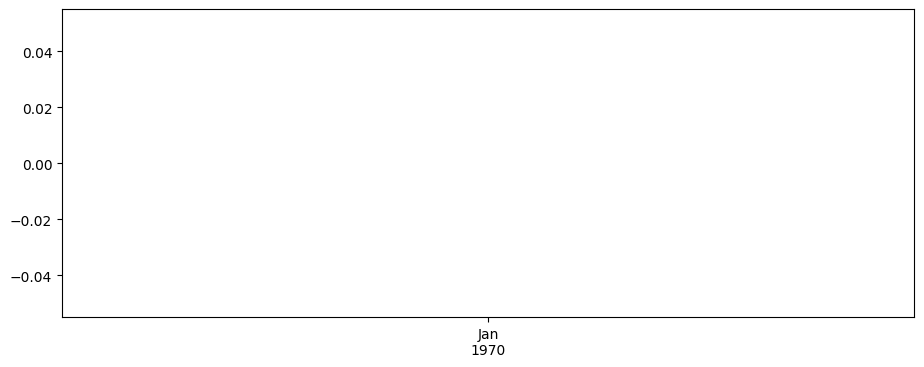

In [13]:
# plot time series plot of posts per month
posts_df['month'] = posts_df['created_at'].dt.to_period('M')
monthly = posts_df.groupby('month').size()

fig, ax = plt.subplots(figsize=(11, 4))
monthly.plot(ax=ax, marker='o', color='steelblue')
ax.set_title('Posts per month')
ax.set_xlabel('Month')
ax.set_ylabel('Post count')
plt.tight_layout()
plt.show()

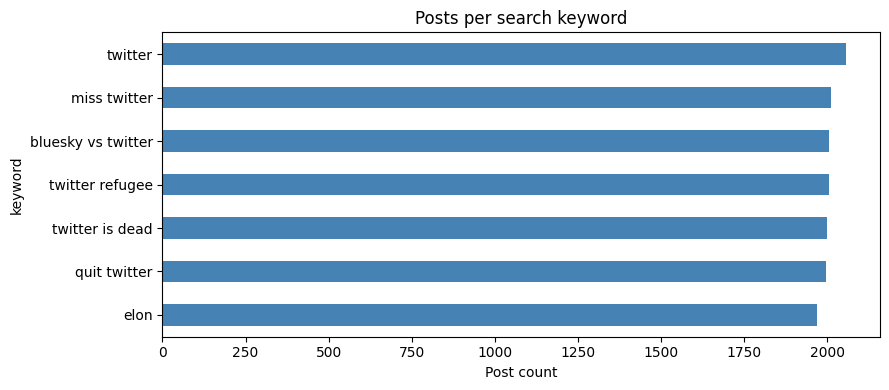

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
posts_df['keyword'].value_counts().sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Posts per search keyword')
ax.set_xlabel('Post count')
plt.tight_layout()
plt.show()

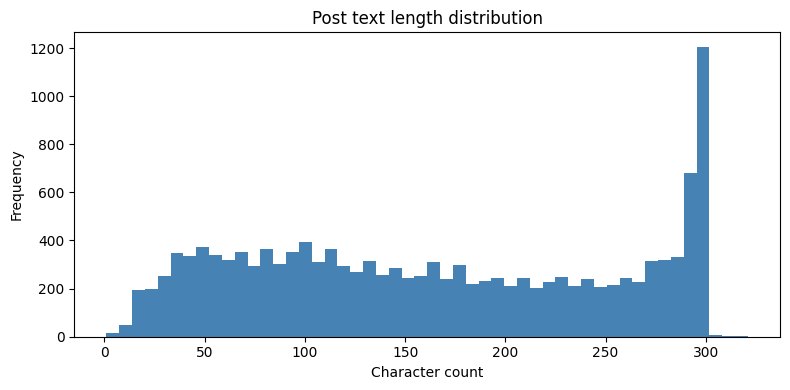

count    13964.0
mean       164.8
std         90.4
min          1.0
25%         86.0
50%        158.0
75%        252.0
max        321.0
Name: text_len, dtype: float64


In [ ]:
posts_df['text_len'] = posts_df['text'].str.len()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(posts_df['text_len'].dropna(), bins=50, color='steelblue', edgecolor='none')
ax.set_title('Post text length distribution')
ax.set_xlabel('Character count')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()
print(posts_df['text_len'].describe().round(1))

In [ ]:
# check empty text
empty_mask = posts_df['text'].isna() | (posts_df['text'].str.strip() == '')
print(f"{empty_mask.sum()} empty posts")

81 empty posts


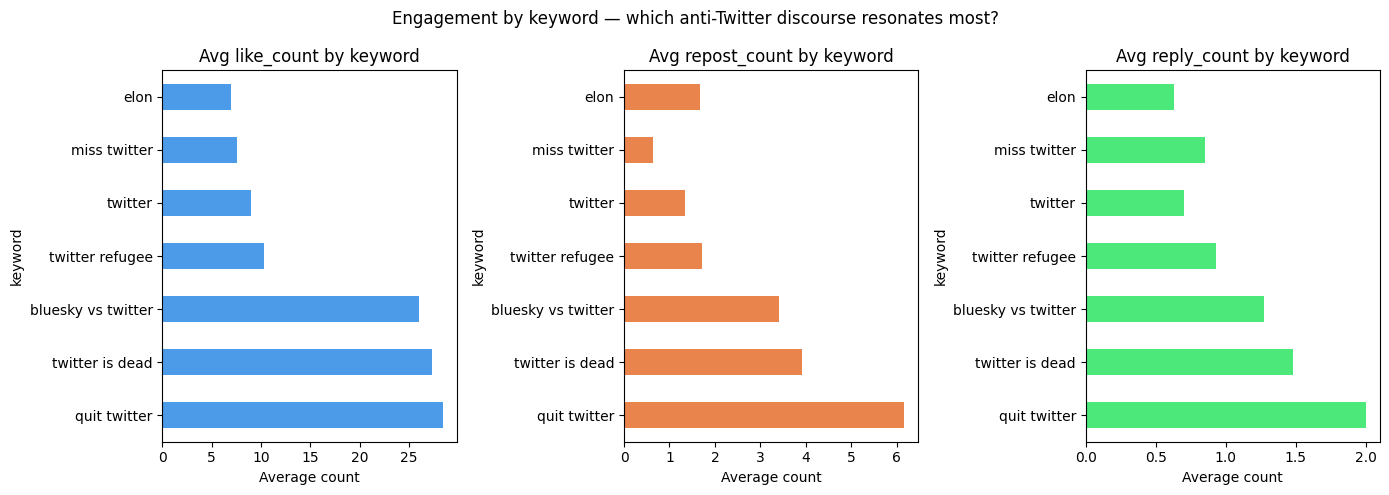

In [ ]:
# Which type of anti-Twitter discourse generates the most engagement?
eng_by_kw = posts_df.groupby('keyword')[['like_count', 'repost_count', 'reply_count']].mean().round(2)
eng_by_kw = eng_by_kw.sort_values('like_count', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['like_count', 'repost_count', 'reply_count']
colours = ['#4C9BE8', '#E8844C', '#4CE87A']
for ax, col, c in zip(axes, metrics, colours):
    eng_by_kw[col].plot(kind='barh', ax=ax, color=c)
    ax.set_title(f'Avg {col} by keyword')
    ax.set_xlabel('Average count')
fig.suptitle('Engagement by keyword — which anti-Twitter discourse resonates most?', fontsize=12)
plt.tight_layout()
plt.show()

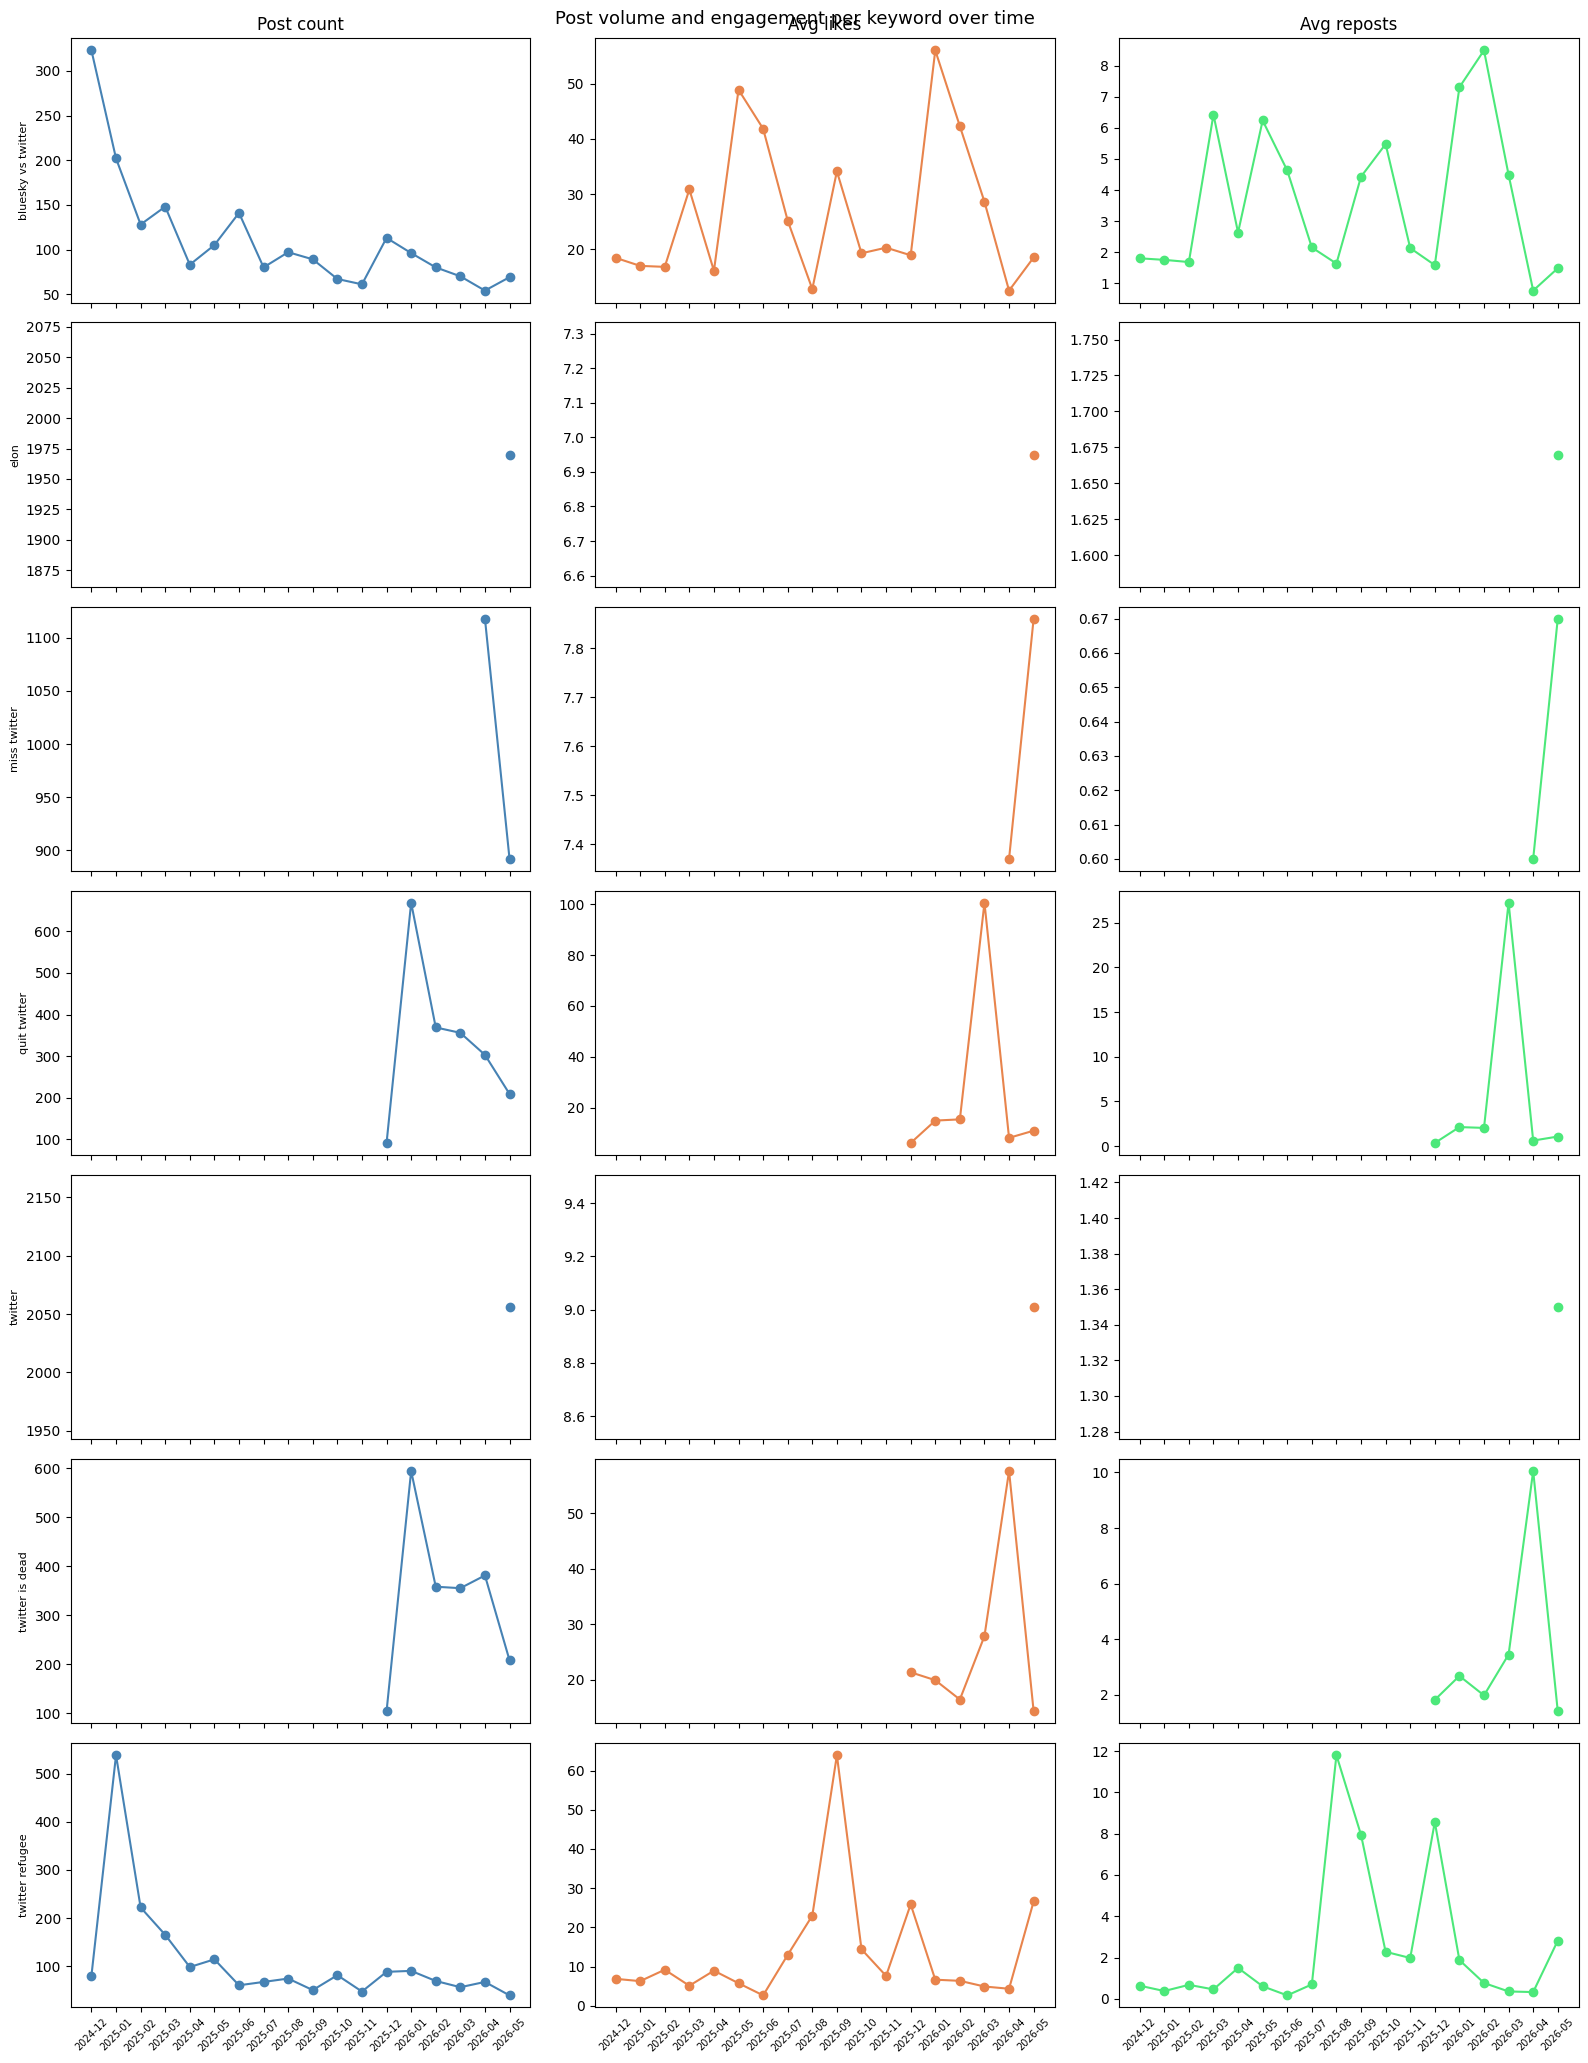

In [ ]:
# Keywords over time — volume and engagement
kw_monthly = posts_df.groupby(['month', 'keyword']).agg(
    post_count=('uri', 'count'),
    avg_likes=('like_count', 'mean'),
    avg_reposts=('repost_count', 'mean')
).round(2)

keywords = posts_df['keyword'].unique()
fig, axes = plt.subplots(len(keywords), 3, figsize=(16, 3 * len(keywords)), sharex=True)

for i, kw in enumerate(sorted(keywords)):
    data = kw_monthly.xs(kw, level='keyword') if kw in kw_monthly.index.get_level_values('keyword') else pd.DataFrame()
    if data.empty:
        continue
    x = data.index.astype(str)

    axes[i, 0].plot(x, data['post_count'], marker='o', color='steelblue')
    axes[i, 0].set_ylabel(kw, fontsize=8)
    if i == 0:
        axes[i, 0].set_title('Post count')

    axes[i, 1].plot(x, data['avg_likes'], marker='o', color='#E8844C')
    if i == 0:
        axes[i, 1].set_title('Avg likes')

    axes[i, 2].plot(x, data['avg_reposts'], marker='o', color='#4CE87A')
    if i == 0:
        axes[i, 2].set_title('Avg reposts')

    for j in range(3):
        axes[i, j].tick_params(axis='x', rotation=45, labelsize=7)

fig.suptitle('Post volume and engagement per keyword over time', fontsize=13)
plt.tight_layout()
plt.show()

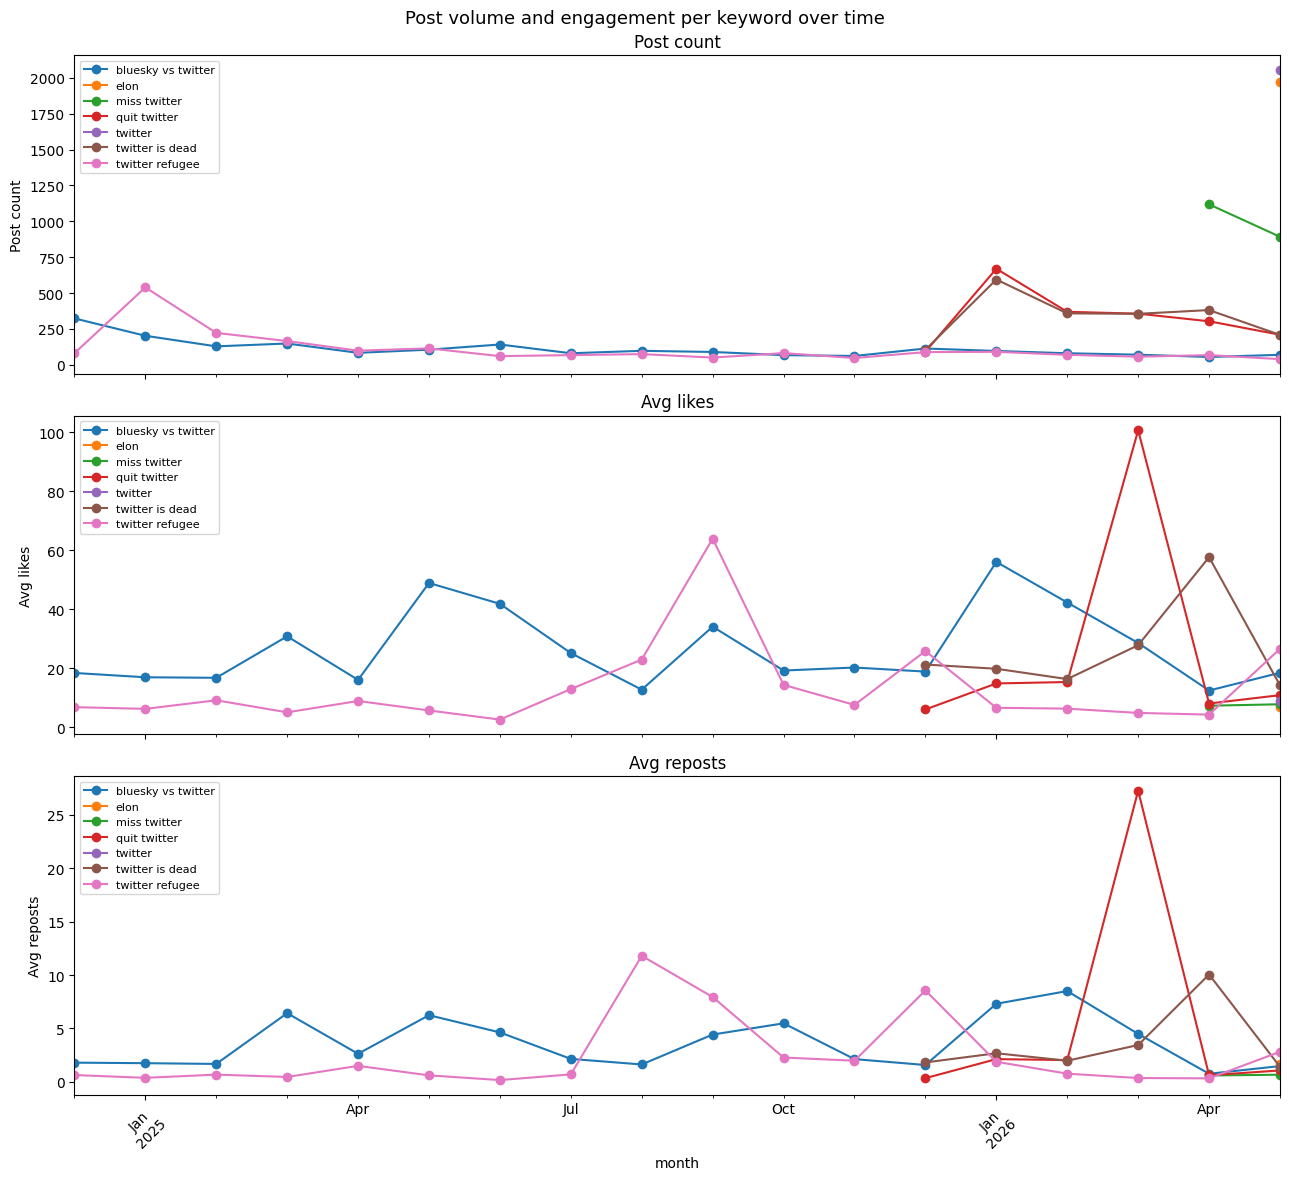

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

metrics = [
    ('post_count', 'Post count', 'count'),
    ('avg_likes', 'Avg likes', 'mean'),
    ('avg_reposts', 'Avg reposts', 'mean')
]

kw_monthly = posts_df.groupby(['month', 'keyword']).agg(
    post_count=('uri', 'count'),
    avg_likes=('like_count', 'mean'),
    avg_reposts=('repost_count', 'mean')
).round(2).unstack('keyword')

for ax, (col, title, _) in zip(axes, metrics):
    kw_monthly[col].plot(ax=ax, marker='o', linewidth=1.5)
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.legend(fontsize=8, loc='upper left')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Post volume and engagement per keyword over time', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
posts_df['author_handle'].value_counts()

author_handle
charlesgaba.com               76
edengk.bsky.social            53
semireflection.bsky.social    27
hltv-mirror.eurosky.social    25
eu-people.bsky.social         22
                              ..
seoultrane.bsky.social         1
xenonbuczynski.bsky.social     1
confdntl.bsky.social           1
taesaveslives.bsky.social      1
themaltesemama.bsky.social     1
Name: count, Length: 11829, dtype: int64

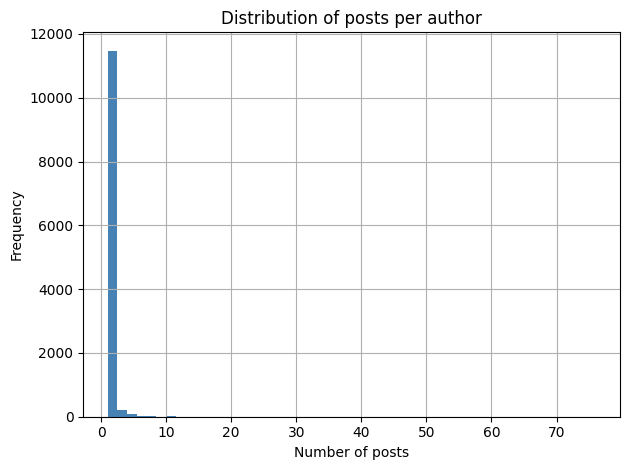

In [ ]:
# distribution of accounts posting
posts_df['author_handle'].value_counts().hist(bins=50, color='steelblue', edgecolor='none')
plt.title('Distribution of posts per author')
plt.xlabel('Number of posts')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()  

In [ ]:
threads = {}

for index, row in posts_df[posts_df['is_reply']].iterrows():
    parent = row['reply_parent']
    if parent not in threads:
        threads[parent] = []
    threads[parent].append(row)

In [ ]:
threads

{'at://did:plc:4za4evmhsstfh3ex2o37weog/app.bsky.feed.post/3mmc4xwfv4s26': [uri              at://did:plc:rrpnky2otfaua3goqxzlsg2q/app.bsky...
  author_handle                   stevesteverers.whaleoilcandles.com
  author_did                        did:plc:rrpnky2otfaua3goqxzlsg2q
  text              I think there's an expert on Twitter you can ask
  created_at                        2026-05-20 14:54:40.483000+00:00
  reply_count                                                      0
  repost_count                                                     0
  quote_count                                                      0
  like_count                                                       0
  is_reply                                                      True
  reply_parent     at://did:plc:4za4evmhsstfh3ex2o37weog/app.bsky...
  keyword                                                    twitter
  month                                                      2026-05
  text_len                   

In [ ]:
len(threads)

6070

In [ ]:
reply_groups = posts_df[posts_df["is_reply"]].groupby("reply_parent")

In [ ]:
reply_groups.size()

reply_parent
at://did:plc:222p42fegwhwfyrc3gqam76j/app.bsky.feed.post/3lpkfisyyf22k    1
at://did:plc:222rnvnta2lbl364bog2plxw/app.bsky.feed.post/3lrg72y5zkc2r    1
at://did:plc:222rnvnta2lbl364bog2plxw/app.bsky.feed.post/3mcaqnlliik2u    1
at://did:plc:222rnvnta2lbl364bog2plxw/app.bsky.feed.post/3me24krbdbk2o    1
at://did:plc:222rnvnta2lbl364bog2plxw/app.bsky.feed.post/3mfs3e3lwmc2i    1
                                                                         ..
at://did:plc:zylv4gasp2fj2f6zqnc6n7zk/app.bsky.feed.post/3mm4r3r5gis2s    1
at://did:plc:zys3icn5r7d3m476di4ttao6/app.bsky.feed.post/3mcch4r3o7k27    1
at://did:plc:zzp52njycx34ecru4tgzwk6v/app.bsky.feed.post/3mmb4zxiznc2a    1
at://did:web:didd.uk/app.bsky.feed.post/3mm3n6grfuc2r                     1
at://did:web:jheya.anaproto.xyz/app.bsky.feed.post/3lihsojwpkc2m          1
Length: 6070, dtype: int64

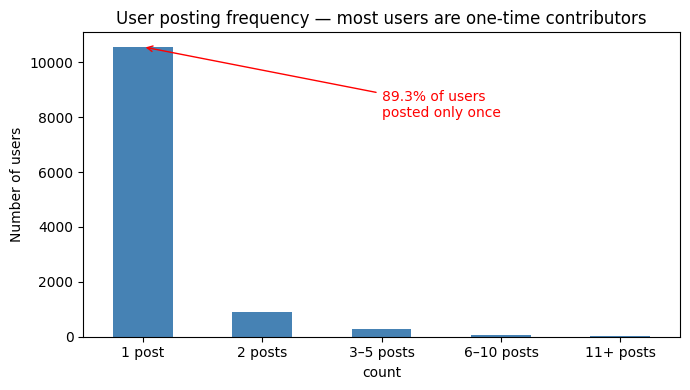

In [ ]:
user_post_counts = posts_df['author_handle'].value_counts()
buckets = pd.cut(user_post_counts, bins=[0,1,2,5,10,100],
                 labels=['1 post', '2 posts', '3–5 posts', '6–10 posts', '11+ posts'])

fig, ax = plt.subplots(figsize=(7, 4))
buckets.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', rot=0)
ax.set_title('User posting frequency — most users are one-time contributors')
ax.set_ylabel('Number of users')
one_time_pct = (user_post_counts == 1).mean()
ax.annotate(f'{one_time_pct:.1%} of users\nposted only once',
            xy=(0, (user_post_counts==1).sum()), xytext=(2, 8000),
            arrowprops=dict(arrowstyle='->', color='red'), color='red')
plt.tight_layout()
plt.show()

# Sentiment Analysis

Using vader sentiment analysis

In [ ]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Apply VADER sentiment analysis to comments
posts_df['vader_score'] = posts_df['text'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
    )

# Classify VADER sentiment (positive, neutral, negative)
# VADER thresholds: positive > 0.05, negative < -0.05, neutral in between
posts_df['vader_class'] = posts_df['vader_score'].apply(
    lambda score: 'Positive' if score > 0.05 else ('Negative' if score < -0.05 else 'Neutral')
)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/benjaminnorrie/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


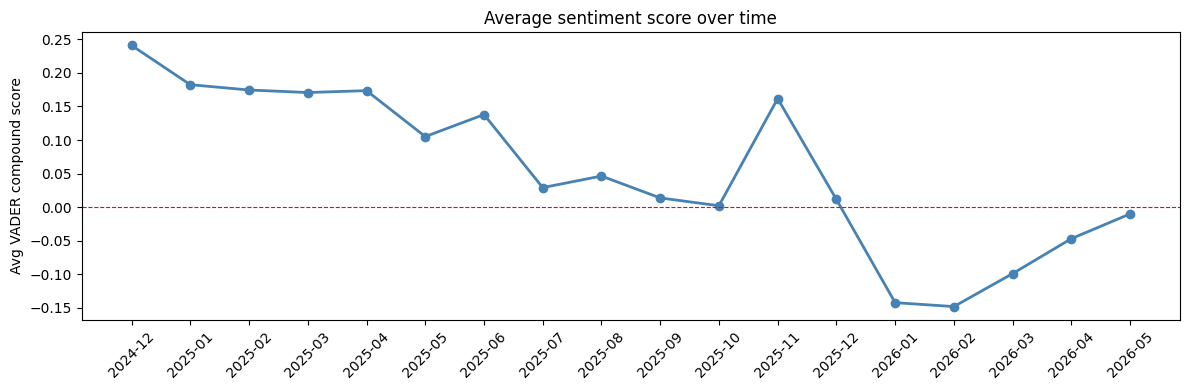

In [ ]:
monthly_sent = posts_df.groupby('month')['vader_score'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_sent.index.astype(str), monthly_sent.values, marker='o', color='steelblue', linewidth=2)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_title('Average sentiment score over time')
ax.set_ylabel('Avg VADER compound score')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

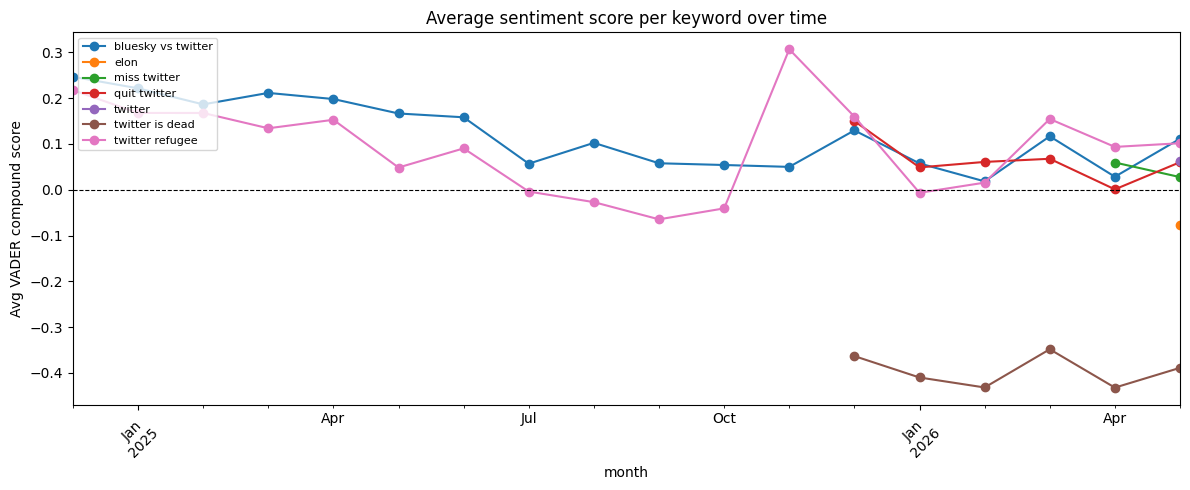

In [ ]:
monthly_kw_sent = posts_df.groupby(['keyword','month'])['vader_score'].mean().unstack('keyword')

fig, ax = plt.subplots(figsize=(12, 5))
monthly_kw_sent.plot(ax=ax, marker='o', linewidth=1.5)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Average sentiment score per keyword over time')
ax.set_ylabel('Avg VADER compound score')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

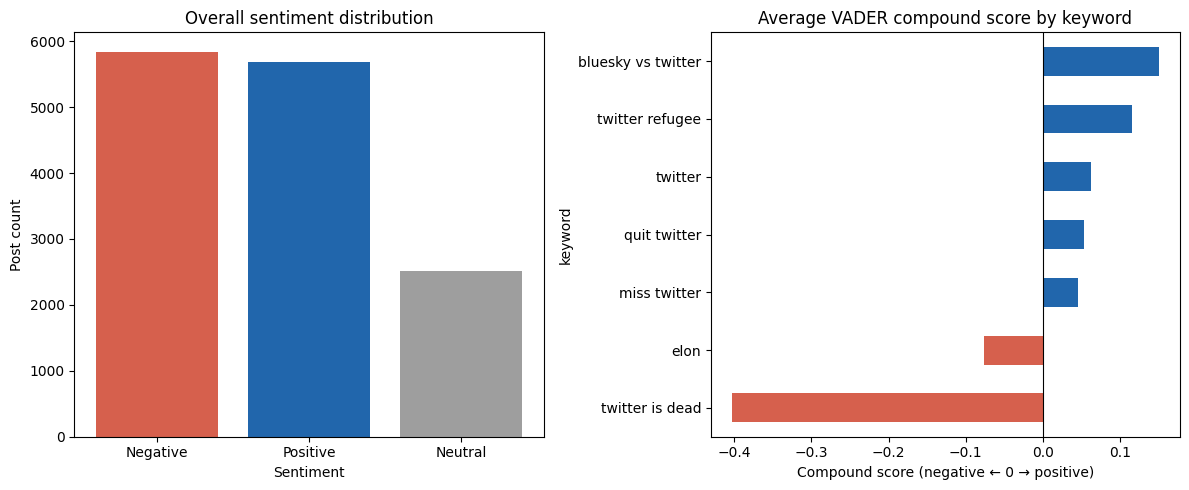

In [ ]:
colours = {'Positive': '#2166AC', 'Neutral': '#9E9E9E', 'Negative': '#D6604D'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
sentiment_counts = posts_df['vader_class'].value_counts()
axes[0].bar(sentiment_counts.index, sentiment_counts.values,
            color=[colours[s] for s in sentiment_counts.index])
axes[0].set_title('Overall sentiment distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Post count')

# Average compound score per keyword
kw_sentiment = posts_df.groupby('keyword')['vader_score'].mean().sort_values()
kw_colours = ['#D6604D' if v < 0 else '#2166AC' for v in kw_sentiment]
kw_sentiment.plot(kind='barh', ax=axes[1], color=kw_colours)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Average VADER compound score by keyword')
axes[1].set_xlabel('Compound score (negative ← 0 → positive)')

plt.tight_layout()
plt.show()

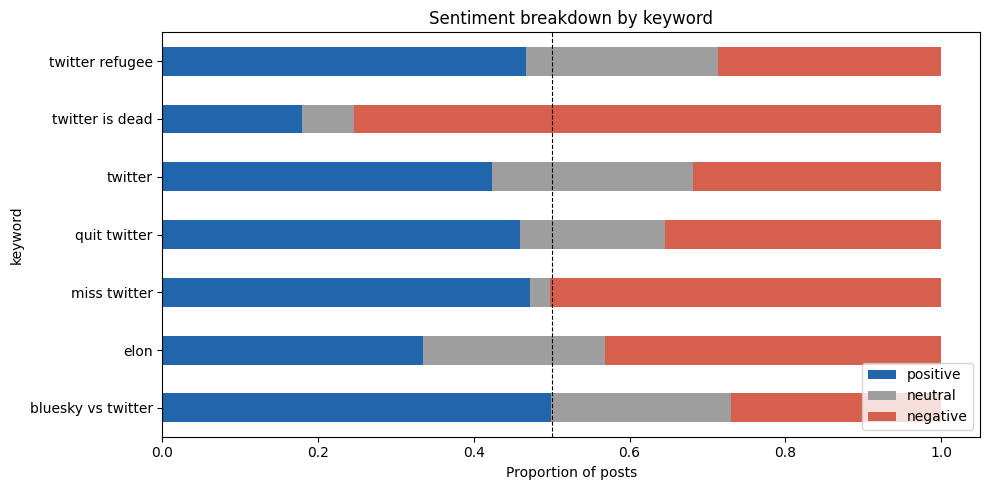

In [ ]:
# Shows proportion of pos/neg/neutral within each keyword
kw_sent = posts_df.groupby(['keyword', 'sentiment']).size().unstack(fill_value=0)
kw_sent_pct = kw_sent.div(kw_sent.sum(axis=1), axis=0)

kw_sent_pct[['positive', 'neutral', 'negative']].plot(
    kind='barh', stacked=True, figsize=(10, 5),
    color=[colours[s] for s in ['positive', 'neutral', 'negative']]
)
plt.title('Sentiment breakdown by keyword')
plt.xlabel('Proportion of posts')
plt.axvline(0.5, color='black', linewidth=0.8, linestyle='--')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Emotion Analysis

In [ ]:
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

import subprocess
from nrclex import NRCLex

subprocess.run(['python3', '-m', 'textblob.download_corpora'], capture_output=True)

CORE_EMOTIONS = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']

def get_emotions(text):
    obj = NRCLex('placeholder')
    obj.load_raw_text(str(text))
    scores = obj.affect_frequencies
    return {e: scores.get(e, 0) for e in CORE_EMOTIONS}

print("Running NRC emotion analysis — this may take a minute...")
emotion_scores = posts_df['text'].apply(get_emotions)
emotion_df = pd.DataFrame(emotion_scores.tolist(), index=posts_df.index)
posts_df = pd.concat([posts_df, emotion_df], axis=1)
print("Done")
print(emotion_df.mean().sort_values(ascending=False).round(4))

Running NRC emotion analysis — this may take a minute...
Done
trust           0.1131
sadness         0.0983
anticipation    0.0766
joy             0.0499
fear            0.0487
anger           0.0452
disgust         0.0354
surprise        0.0307
dtype: float64


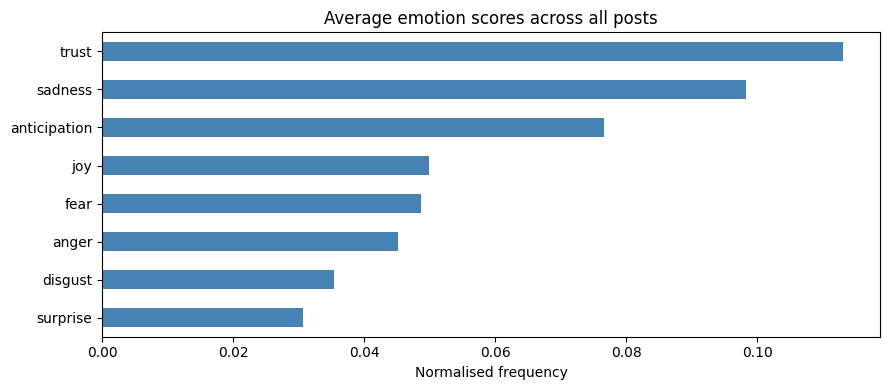

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
emotion_df[CORE_EMOTIONS].mean().sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Average emotion scores across all posts')
ax.set_xlabel('Normalised frequency')
plt.tight_layout()
plt.show()

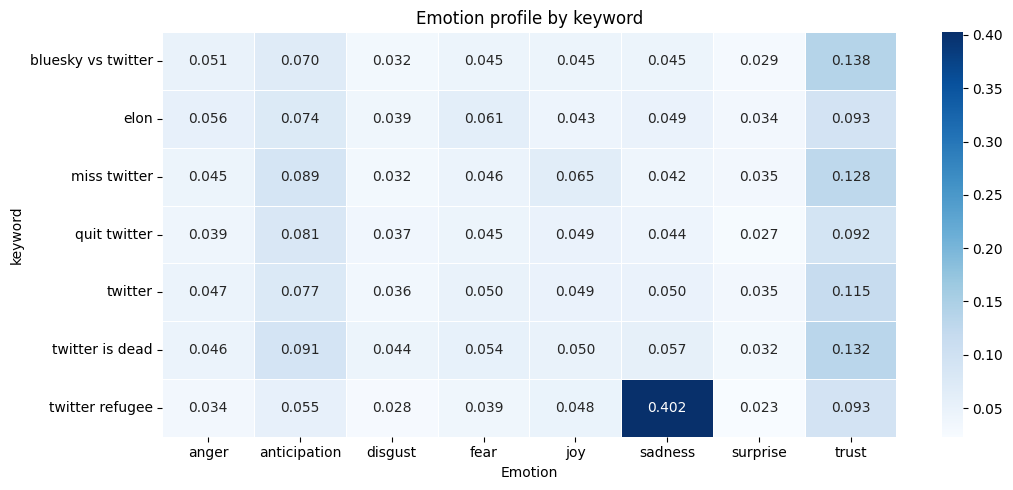

In [ ]:
kw_emotions = posts_df.groupby('keyword')[CORE_EMOTIONS].mean()

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(kw_emotions, annot=True, fmt='.3f', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Emotion profile by keyword')
ax.set_xlabel('Emotion')
plt.tight_layout()
plt.show()

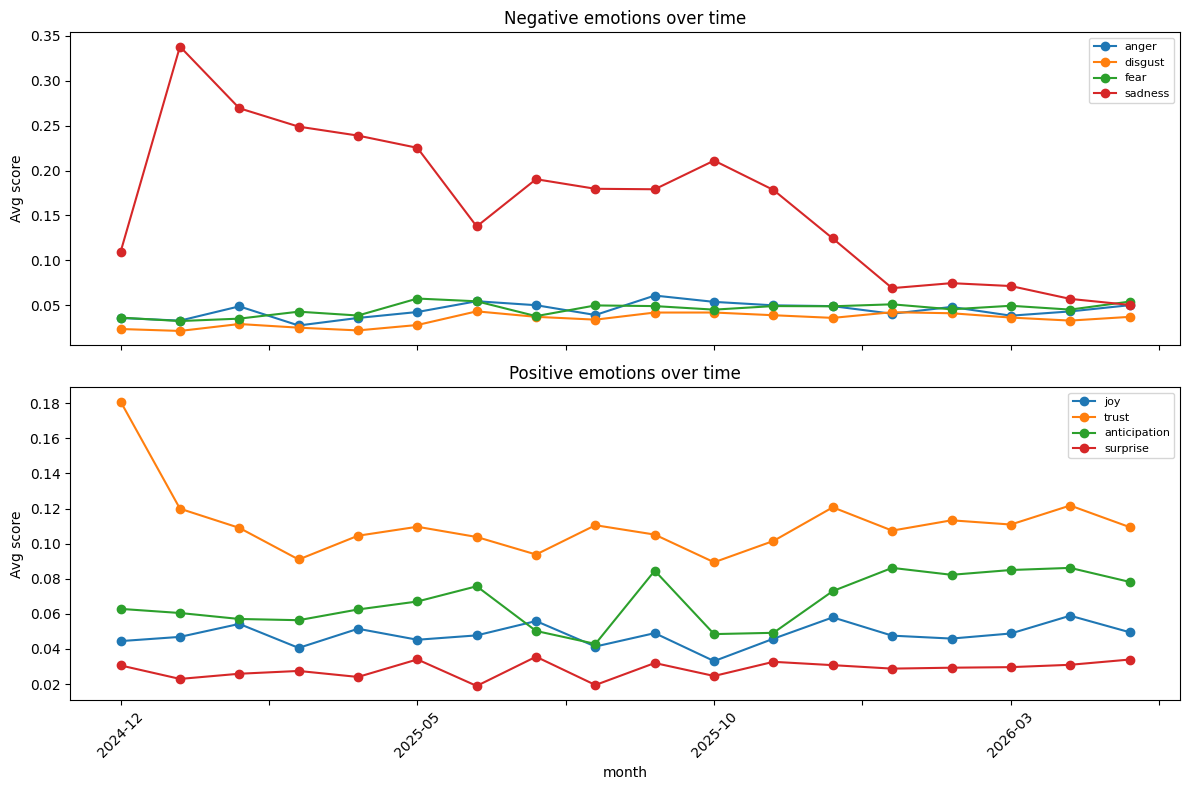

In [ ]:
# Group emotions into meaningful clusters for readability
NEGATIVE_EMOTIONS = ['anger', 'disgust', 'fear', 'sadness']
POSITIVE_EMOTIONS = ['joy', 'trust', 'anticipation', 'surprise']

monthly_emotions = posts_df.groupby('month')[CORE_EMOTIONS].mean()
monthly_emotions.index = monthly_emotions.index.astype(str)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

monthly_emotions[NEGATIVE_EMOTIONS].plot(ax=axes[0], marker='o', linewidth=1.5)
axes[0].set_title('Negative emotions over time')
axes[0].set_ylabel('Avg score')
axes[0].legend(fontsize=8)

monthly_emotions[POSITIVE_EMOTIONS].plot(ax=axes[1], marker='o', linewidth=1.5)
axes[1].set_title('Positive emotions over time')
axes[1].set_ylabel('Avg score')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
top10 = posts_df.nlargest(10, 'vader_score')[['text', 'vader_score']]
bottom10 = posts_df.nsmallest(10, 'vader_score')[['text', 'vader_score']]

print("Most Positive")
for _, row in top10.iterrows():
    print(f"[{row['vader_score']:.3f}] {row['text']}\n")

=== Most Positive ===
[0.982] Wow! I've been here on Bluesky now a month as Twitter refugee. It's great to see so many a wonderful folk sharing their experiences and great photos. I now have 200 followers, you are amazing, all of you! Thank you for the shares, feeling in the pink. #photography #photos #thanks #feelingthelove

[0.982] Awwwe!  Wonderful - great fun in a car ride. You are definitely a great spokesperson for clean energy. Moon is how I found you - that & the Fry's photo you posted on Twitter when I was actually at Fry's.You're adorable & seriously, my son kind of looks like you, so feeling the mom thing w/o apology

[0.976] This happy-clappy denial of any failures under D administrations is not only why I unfollowed Stancil back on Twitter, but why I gave up on national politics for years & just focused on local activism. Total denial of the truths honest Ds like Robert Reich expose—our rich only get richer, regardless

[0.976] Hugz and kisses from a Twitter refugee who al

In [ ]:
print("Most Negative")
for _, row in bottom10.iterrows():
    print(f"[{row['vader_score']:.3f}] {row['text']}\n")

=== Most Negative ===
[-0.995] Kk killer /DD killer is Elon musk 

I will sue him .

1)Sin(g)(k)awang = cis, sis, sg, z anger, singer, anger,  Singapore, coven, Avon, anger,
Wang is anger, kevin anger, sick kevin is anger, gawang = gaving anger, gay one anger, 
SIN ANGER! 

SECOND! ONE ANGER!

[-0.995] singkawang= singer sick coven, one, wan anger, 
cake anger /Odense/Otec father, Ake pope anger 
kasang /kawang/cake anger /king /kaang anger ! 
king anger ! 

sick /king anger (:
fuck off blue shit

second /one anger !

fuck off z snakes !! criminal z Elon musk!!! avoid blue shits!

[-0.988] 3. Ironically I find bsky less welcoming. Everything is evil. Vercel is evil, Cloudflare is evil, AI is evil, family is evil, faith is evil - basically everything is evil (except the person posting, of course). I’m evil for this opinion.

I miss old dev twitter.

[-0.984] Back and forth hate, hate for hate #HateVsHate of MAGA since year 2013 is a feedback loop of Reddit vs. Facebook, now Twitter vs. 

In [ ]:
posts_df.sort_values(by="vader_score", ascending=True).head(10)

,uri,author_handle,author_did,text,created_at,reply_count,repost_count,quote_count,like_count,is_reply,...,vader_score,vader_class,anger,anticipation,disgust,fear,joy,sadness,surprise,trust
2213,at://did:plc:xqwhmerd4grgnkmndwyyv3kv/app.bsky...,dsards92.bsky.social,did:plc:xqwhmerd4grgnkmndwyyv3kv,Kk killer /DD killer is Elon musk \n\nI will s...,2026-05-20 13:23:51.432000+00:00,3,0,0,0,False,...,-0.9954,Negative,0.409091,0.000000,0.045455,0.000000,0.000000,0.090909,0.000000,0.000000
2176,at://did:plc:xqwhmerd4grgnkmndwyyv3kv/app.bsky...,dsards92.bsky.social,did:plc:xqwhmerd4grgnkmndwyyv3kv,"singkawang= singer sick coven, one, wan anger,...",2026-05-20 13:44:56.541000+00:00,1,0,0,0,False,...,-0.9950,Negative,0.234043,0.000000,0.127660,0.085106,0.000000,0.106383,0.000000,0.021277
13986,at://did:plc:5xbghy4r6c5bhoy7d5f7p3if/app.bsky...,jpschroeder.com,did:plc:5xbghy4r6c5bhoy7d5f7p3if,3. Ironically I find bsky less welcoming. Ever...,2026-04-10 15:47:43.070000+00:00,1,0,0,3,True,...,-0.9876,Negative,0.181818,0.022727,0.181818,0.181818,0.022727,0.181818,0.000000,0.022727
6522,at://did:plc:rwyn2e7jpkbhgnmruwj5tqoq/app.bsky...,roundsparrow.bsky.social,did:plc:rwyn2e7jpkbhgnmruwj5tqoq,"Back and forth hate, hate for hate #HateVsHate...",2025-12-18 11:38:18.650000+00:00,1,1,0,1,True,...,-0.9840,Negative,0.176471,0.000000,0.176471,0.205882,0.000000,0.176471,0.000000,0.029412
9896,at://did:plc:fjlczd3nixi4pxtqfm3vk4g7/app.bsky...,gingeralepale.bsky.social,did:plc:fjlczd3nixi4pxtqfm3vk4g7,Violent speech??? This was considered violent ...,2026-01-05 16:59:44.192000+00:00,0,0,0,1,True,...,-0.9833,Negative,0.125000,0.000000,0.125000,0.208333,0.000000,0.083333,0.041667,0.041667
8869,at://did:plc:gr4fgk6banc65ls62upbeazd/app.bsky...,tiza.bsky.social,did:plc:gr4fgk6banc65ls62upbeazd,I miss Posting but I don't feel like I have an...,2026-03-15 09:46:48.292000+00:00,2,1,0,6,False,...,-0.9832,Negative,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10571,at://did:plc:4hzp3t6khako2ohwnfdbvgyn/app.bsky...,thekillerr4bbit.bsky.social,did:plc:4hzp3t6khako2ohwnfdbvgyn,I don't know if you even see this but I just g...,2026-04-04 20:20:55.285000+00:00,0,0,0,0,False,...,-0.9818,Negative,0.285714,0.000000,0.285714,0.000000,0.000000,0.000000,0.000000,0.000000
9011,at://did:plc:mpkuwz6fikdfl54lxgawnuk6/app.bsky...,mudkri.bsky.social,did:plc:mpkuwz6fikdfl54lxgawnuk6,As an alternative to twitter this place is agg...,2026-03-02 18:55:31.060000+00:00,2,0,1,3,False,...,-0.9807,Negative,0.055556,0.055556,0.055556,0.277778,0.055556,0.055556,0.000000,0.000000
1090,at://did:plc:pgze3alcbnl6ssowxa3urjlf/app.bsky...,kaydenf07.bsky.social,did:plc:pgze3alcbnl6ssowxa3urjlf,"Can leakers just, like, not? For once? I’m sma...",2026-05-20 04:04:35.604000+00:00,0,0,0,0,False,...,-0.9806,Negative,0.214286,0.071429,0.142857,0.071429,0.000000,0.071429,0.000000,0.000000
483,at://did:plc:dflosfsa73xjfghxktocggqd/app.bsky...,solidbeato.bsky.social,did:plc:dflosfsa73xjfghxktocggqd,"Not to be a ""radfem"" but porn companies are al...",2026-05-20 11:11:47.967000+00:00,1,0,0,13,False,...,-0.9777,Negative,0.111111,0.037037,0.148148,0.111111,0.037037,0.148148,0.000000,0.111111


## Topic Modelling

In [ ]:

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer

import numpy as np
import string
import pyLDAvis
import pyLDAvis.lda_model
import wordcloud

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation


In [ ]:
def processText(text, tokenizer, lemmatizer, stopwords):
    """
    Perform tokenisation, normalisation (lower case and stemming) and stopword removal.

    @param text: YouTube video title and/or description
    @param tokenizer: tokeniser used.
    @param stemmer: stemmer used.
    @param stopwords: list of stopwords used

    @returns: a list of processed tokens
    """

    # tokenise and covert all to lower case
    lTokens = tokenizer.tokenize(text.lower())
    # strip whitespaces before and after
    lTokens = [token.strip() for token in lTokens]
    # stem (we use set to remove duplicates)
    lLemmTokens = set([lemmatizer.lemmatize(tok) for tok in lTokens])

    # remove stopwords, digits
    return [tok for tok in lLemmTokens 
            if tok not in stopwords 
            and not tok.isdigit()
            and len(tok) > 2]

In [ ]:
# tokeniser to use for social-media style text
postTokeniser = TweetTokenizer()
# use the punctuation symbols defined in string.punctuation
lPunct = list(string.punctuation)
# use stopwords from nltk and a few web / YouTube specific terms
lStopwords = nltk.corpus.stopwords.words('english') + lPunct + [
    'via', 'amp', 'http', 'https', 'www', 'com',
    'youtube', 'youtu', 'video', 'videos', 'channel', 'watch'
]

# use the wordNet Lemmatizer - less aggressive than stemmer
postLammatizer = WordNetLemmatizer()

posts_df['tokens'] = posts_df['text'].apply(
    lambda x : processText(x, postTokeniser, postLammatizer, lStopwords)
    )


TypeError: processText() missing 4 required positional arguments: 'text', 'tokenizer', 'stemmer', and 'stopwords'

In [ ]:
# LDA parameters #

# number of topics to discover (default = 10)
topicNum = 10
# maximum number of words to display per topic (default = 10)
# Exercise 1: change this to 20
wordNumToDisplay = 10
# this is the number of features/words used to describe our documents
# please feel free to change to see the effect
featureNum = 1500

In [ ]:
#
# Count Vectorizer
#

tfVectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=featureNum, stop_words='english')
tf = tfVectorizer.fit_transform()
# extract the names of the features (in our case, the words)
tfFeatureNames = tfVectorizer.get_feature_names_out()

#
# LDA MODEL
#

# Run LDA (see documentation about what the arguments mean)
ldaModel = LatentDirichletAllocation(n_components=topicNum, max_iter=10, learning_method='online').fit(tf)

In [ ]:
def display_topics(model, featureNames, numTopWords):
    """
    Prints out the most associated words for each topic.

    @param model: lda model.
    @param featureNames: list of strings, representing the list of features/words.
    @param numTopWords: number of words to print per topic.
    """

    # print out the topic distributions
    for topicId, lTopicDist in enumerate(model.components_):
        print('Topic %d:' % (topicId + 1))
        print(' '.join([featureNames[i] for i in lTopicDist.argsort()[:-numTopWords - 1:-1]]))